<a href="https://colab.research.google.com/github/jeevana16/my-first-repo/blob/main/module2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# 2. MISSING VALUE HANDLING
# ============================================================

print("\n" + "=" * 60)
print("2. MISSING VALUE HANDLING")
print("=" * 60)

clean_df = df.copy()

for column in missing_percentage.index:

    missing_rate = missing_percentage[column]

    print(f"\nColumn: {column}")
    print(f"Missing percentage: {missing_rate:.2f}%")

    # Under 5% -> drop rows
    if missing_rate < 5:

        print("Strategy: Drop rows")

        clean_df = clean_df.dropna(
            subset=[column]
        )

    # 5% to 30% -> impute
    elif missing_rate <= 30:

        print("Strategy: Impute")

        if pd.api.types.is_numeric_dtype(
            clean_df[column]
        ):

            median_value = clean_df[column].median()

            clean_df[column] = clean_df[column].fillna(
                median_value
            )

            print(
                f"Imputed using median: {median_value}"
            )

        else:

            mode_value = clean_df[column].mode()[0]

            clean_df[column] = clean_df[column].fillna(
                mode_value
            )

            print(
                f"Imputed using mode: {mode_value}"
            )

    # More than 30% -> drop column
    else:

        print(
            "Strategy: Drop column because "
            "missingness is too high for reliable imputation."
        )

        clean_df = clean_df.drop(
            columns=[column]
        )


# ============================================================
# SAVE CLEANED DATASET
# ============================================================

clean_df.to_csv(
    "titanic_clean.csv",
    index=False
)

print(
    "\nCleaned dataset saved as titanic_clean.csv"
)

print(
    "\nCleaned shape:",
    clean_df.shape
)


2. MISSING VALUE HANDLING

Column: deck
Missing percentage: 77.22%
Strategy: Drop column because missingness is too high for reliable imputation.

Column: age
Missing percentage: 19.87%
Strategy: Impute
Imputed using median: 28.0

Column: embarked
Missing percentage: 0.22%
Strategy: Drop rows

Column: embark_town
Missing percentage: 0.22%
Strategy: Drop rows

Cleaned dataset saved as titanic_clean.csv

Cleaned shape: (889, 14)


TASK 7 - LOAD CLEANED DATA

Dataset shape:
(889, 14)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town alive  alone  
0    man        True  Southampton    no  False  
1  woman       False    Cherbourg   yes  False  
2  woman       False  Southampton   yes   True  
3  woman       False  Southampton   yes  False  
4    man        True  Southampton    no   True  

CLASS BALANCE

Class counts:
sur

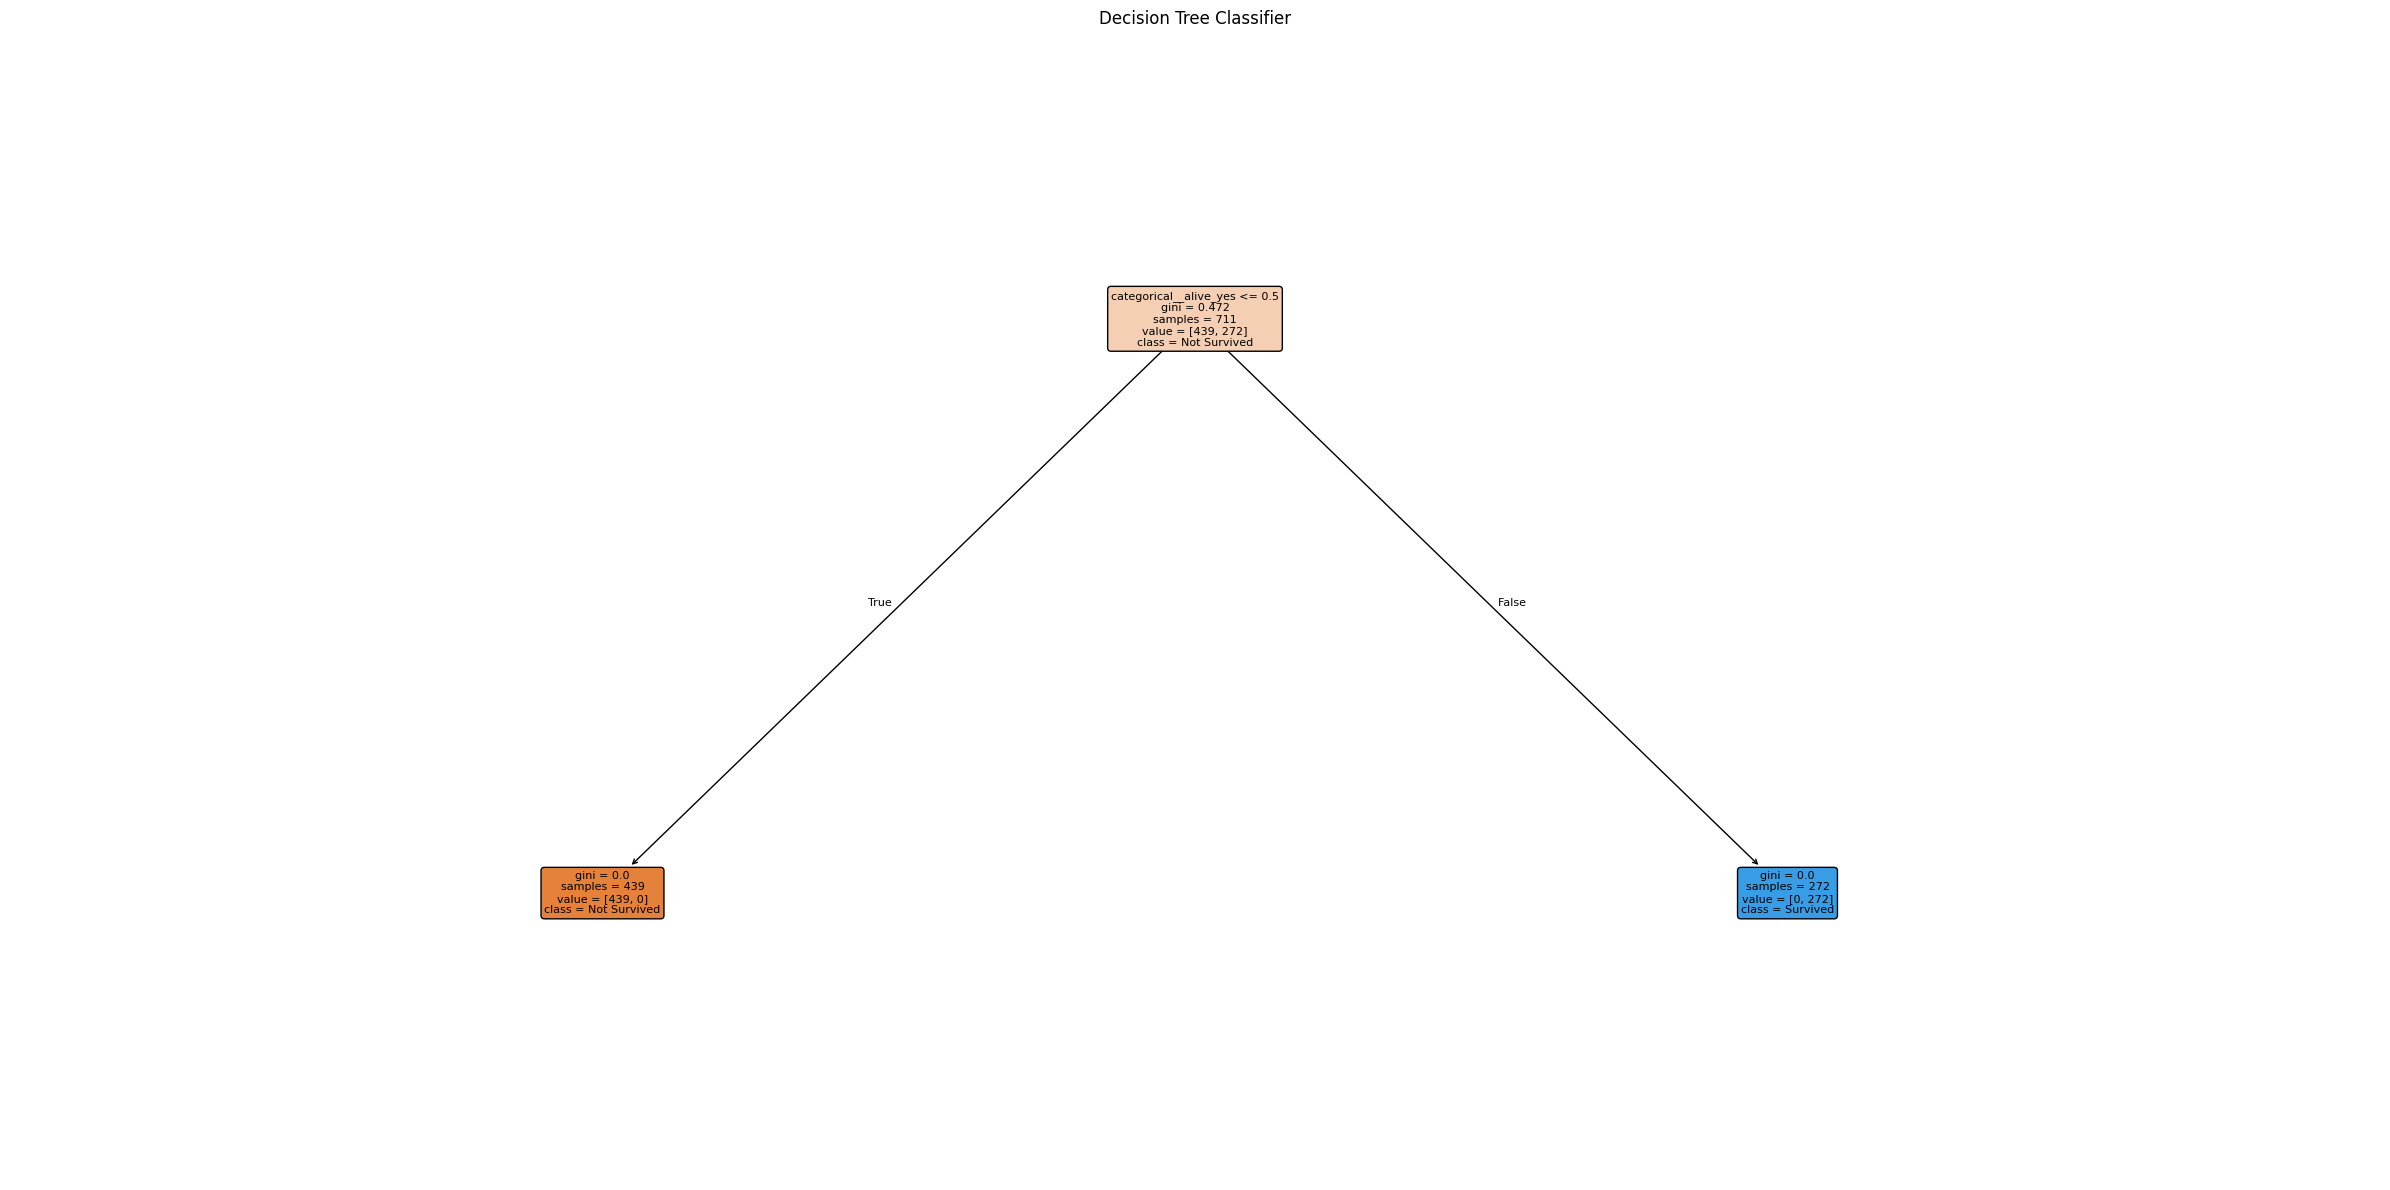


CLASSIFICATION MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1  AUC
Logistic Regression       1.0        1.0     1.0 1.0  1.0
      Decision Tree       1.0        1.0     1.0 1.0  1.0
      Random Forest       1.0        1.0     1.0 1.0  1.0


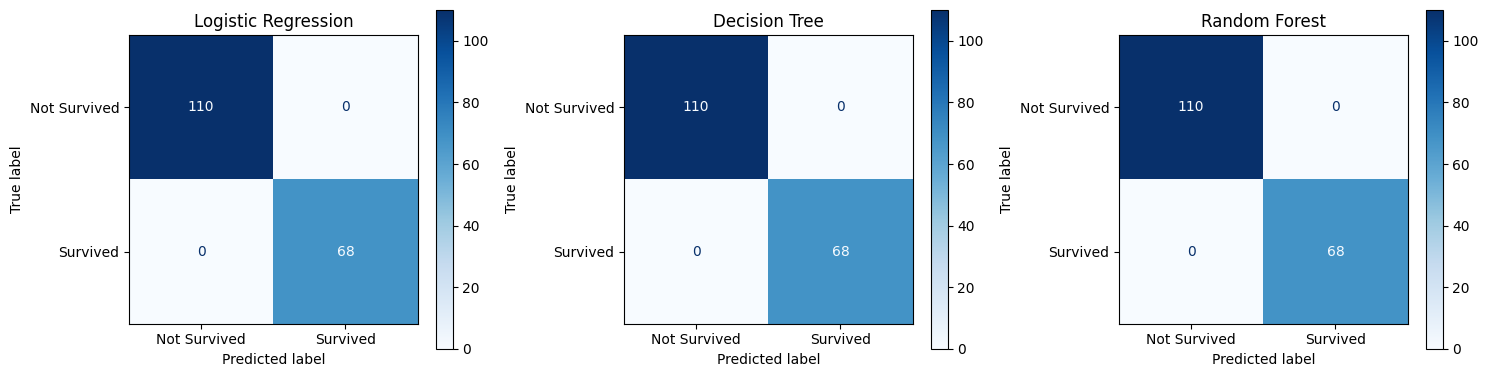

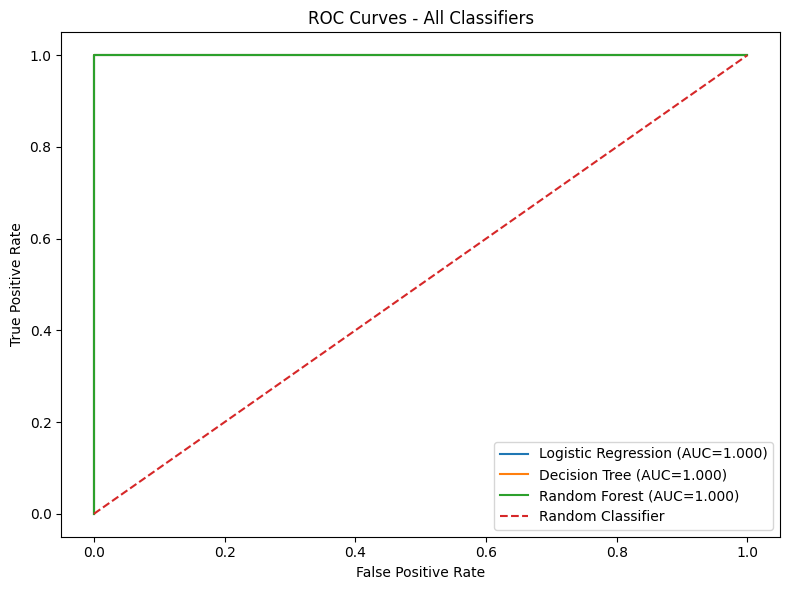


TASK 11 - IMBALANCE HANDLING

Original training class balance:
survived
0    439
1    272
Name: count, dtype: int64

Applying SMOTE only to training data...

Class balance after SMOTE:
survived
1    439
0    439
Name: count, dtype: int64

IMBALANCE COMPARISON
               Strategy  Precision  Recall  F1
               Baseline        1.0     1.0 1.0
class_weight='balanced'        1.0     1.0 1.0
                  SMOTE        1.0     1.0 1.0

Conclusion:
Based on F1 score, the strategy with the highest F1 score
in this test is: Baseline.

Precision measures the proportion of predicted survivors that
were actually survivors.

Recall measures the proportion of actual survivors that were
correctly identified.

F1 balances precision and recall.


TASK 12 - RANDOM FOREST HYPERPARAMETER TUNING

Running GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators'

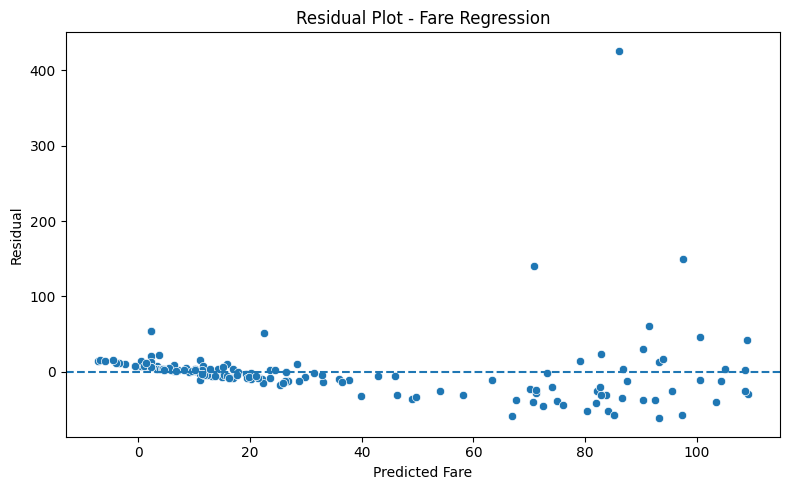


Heteroscedasticity interpretation:
If the residuals show a roughly constant random spread around zero,
there is no strong visual evidence of heteroscedasticity.

If the spread increases or decreases systematically as predicted
fare increases, the residuals indicate heteroscedasticity.


TASK 14 - FINAL MODEL COMPARISON

--- CLASSIFICATION METRICS ---
              Model  Accuracy  Precision  Recall  F1  AUC
Logistic Regression       1.0        1.0     1.0 1.0  1.0
      Decision Tree       1.0        1.0     1.0 1.0  1.0
      Random Forest       1.0        1.0     1.0 1.0  1.0

--- REGRESSION METRICS ---
 Regression Model       MAE      RMSE       R2  Adjusted_R2
Linear Regression 18.261671 41.276362 0.361404     0.275439

Final recommendation based on the observed test metrics:

The classifier with the highest F1 score in this experiment is
Logistic Regression.

Its:
Precision = 1.0000
Recall    = 1.0000
F1        = 1.0000
AUC       = 1.0000

F1 was considered because it combines pr

In [5]:
# ============================================================
# MODULE 2 - ANALYTICS PIPELINE
# PART B - PREDICTIVE MODELING
# TASKS 7 - 15
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.base import clone

from imblearn.over_sampling import SMOTE

from imblearn.pipeline import Pipeline as ImbPipeline


# ============================================================
# 7. LOAD CLEANED DATA
# ============================================================

print("=" * 70)
print("TASK 7 - LOAD CLEANED DATA")
print("=" * 70)

df = pd.read_csv("titanic_clean.csv")

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# CLASS BALANCE
# ============================================================

print("\n" + "=" * 70)
print("CLASS BALANCE")
print("=" * 70)

class_counts = df["survived"].value_counts().sort_index()

class_percentages = (
    df["survived"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nClass counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages)

print("\n0 = Not Survived")
print("1 = Survived")


# ============================================================
# DEFINE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["survived"])

y = df["survived"]


# ============================================================
# REMOVE TARGET-LEAKAGE / REDUNDANT COLUMNS
# ============================================================

# We do not use the target itself.
#
# adult_male and alone are derived/redundant flags and were
# specifically excluded from the correlation analysis.
#
# deck has substantial missingness and is not necessary for
# this modeling pipeline.

columns_to_drop = [
    "adult_male",
    "alone",
    "deck"
]

columns_to_drop = [
    col for col in columns_to_drop
    if col in X.columns
]

X = X.drop(columns=columns_to_drop)

print("\nFeatures used for modeling:")
print(X.columns.tolist())


# ============================================================
# STRATIFIED TRAIN/TEST SPLIT
# ============================================================

print("\n" + "=" * 70)
print("TASK 7 - STRATIFIED TRAIN / TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining shape:")
print(X_train.shape)

print("\nTesting shape:")
print(X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

print(
    """
Why stratification?
The target contains two classes: survived and not survived.
Stratification keeps approximately the same class proportion in both
training and testing datasets, making model evaluation more reliable.
"""
)


# ============================================================
# 8. PREPROCESSING
# ============================================================

print("\n" + "=" * 70)
print("TASK 8 - PREPROCESSING PIPELINE")
print("=" * 70)


# ------------------------------------------------------------
# IDENTIFY NUMERIC AND CATEGORICAL FEATURES
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ------------------------------------------------------------
# NUMERIC PIPELINE
# ------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# CATEGORICAL PIPELINE
# ------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ------------------------------------------------------------
# COLUMN TRANSFORMER
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


print(
    """
Preprocessing:
Numeric:
    Missing values -> median
    Scaling -> StandardScaler

Categorical:
    Missing values -> most frequent
    Encoding -> OneHotEncoder

All preprocessing is fitted only on training data through
the sklearn Pipeline.
"""
)


# ============================================================
# 9. THREE CLASSIFIERS
# ============================================================

print("\n" + "=" * 70)
print("TASK 9 - TRAIN THREE CLASSIFIERS")
print("=" * 70)


# ------------------------------------------------------------
# LOGISTIC REGRESSION
# ------------------------------------------------------------

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# DECISION TREE
# ------------------------------------------------------------

tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------------------

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# TRAIN MODELS
# ------------------------------------------------------------

print("\nTraining Logistic Regression...")

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression trained.")


print("\nTraining Decision Tree...")

tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree trained.")


print("\nTraining Random Forest...")

rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest trained.")


# ============================================================
# DECISION TREE VISUALIZATION
# ============================================================

print("\n" + "=" * 70)
print("DECISION TREE VISUALIZATION")
print("=" * 70)


tree_model = tree_pipeline.named_steps[
    "classifier"
]

tree_preprocessor = tree_pipeline.named_steps[
    "preprocessor"
]


# Get transformed feature names

try:

    feature_names = (
        tree_preprocessor
        .get_feature_names_out()
    )

except Exception:

    feature_names = None


plt.figure(
    figsize=(24, 12)
)

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[
        "Not Survived",
        "Survived"
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Decision Tree Classifier"
)

plt.tight_layout()

plt.savefig(
    "decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_classifier(
    model,
    X_test,
    y_test,
    model_name
):

    y_pred = model.predict(X_test)

    # Probability for ROC
    if hasattr(model, "predict_proba"):

        y_probability = model.predict_proba(
            X_test
        )[:, 1]

    else:

        y_probability = model.decision_function(
            X_test
        )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "Confusion Matrix": cm,
        "Predictions": y_pred,
        "Probabilities": y_probability
    }


# ============================================================
# EVALUATE ALL THREE MODELS
# ============================================================

logistic_results = evaluate_classifier(
    logistic_pipeline,
    X_test,
    y_test,
    "Logistic Regression"
)

tree_results = evaluate_classifier(
    tree_pipeline,
    X_test,
    y_test,
    "Decision Tree"
)

rf_results = evaluate_classifier(
    rf_pipeline,
    X_test,
    y_test,
    "Random Forest"
)


results = [
    logistic_results,
    tree_results,
    rf_results
]


# ============================================================
# COMPARISON TABLE
# ============================================================

classification_results = pd.DataFrame(
    [
        {
            "Model": r["Model"],
            "Accuracy": r["Accuracy"],
            "Precision": r["Precision"],
            "Recall": r["Recall"],
            "F1": r["F1"],
            "AUC": r["AUC"]
        }
        for r in results
    ]
)

print("\n" + "=" * 70)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 70)

print(
    classification_results.to_string(
        index=False
    )
)


# Save table

classification_results.to_csv(
    "classification_results.csv",
    index=False
)


# ============================================================
# CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for ax, result in zip(
    axes,
    results
):

    ConfusionMatrixDisplay(
        confusion_matrix=result[
            "Confusion Matrix"
        ],
        display_labels=[
            "Not Survived",
            "Survived"
        ]
    ).plot(
        ax=ax,
        cmap="Blues"
    )

    ax.set_title(
        result["Model"]
    )

plt.tight_layout()

plt.savefig(
    "confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# ROC CURVES
# ============================================================

plt.figure(
    figsize=(8, 6)
)

for result in results:

    fpr, tpr, _ = roc_curve(
        y_test,
        result["Probabilities"]
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f'{result["Model"]} '
            f'(AUC={result["AUC"]:.3f})'
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves - All Classifiers"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. IMBALANCE HANDLING
# ============================================================

print("\n" + "=" * 70)
print("TASK 11 - IMBALANCE HANDLING")
print("=" * 70)


print("\nOriginal training class balance:")

print(
    y_train.value_counts()
)


# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------

baseline_model = clone(
    logistic_pipeline
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_pred = baseline_model.predict(
    X_test
)


baseline_precision = precision_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)


# ------------------------------------------------------------
# CLASS WEIGHT BALANCED
# ------------------------------------------------------------

balanced_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_pipeline.fit(
    X_train,
    y_train
)

balanced_pred = balanced_pipeline.predict(
    X_test
)

balanced_precision = precision_score(
    y_test,
    balanced_pred,
    zero_division=0
)

balanced_recall = recall_score(
    y_test,
    balanced_pred,
    zero_division=0
)

balanced_f1 = f1_score(
    y_test,
    balanced_pred,
    zero_division=0
)


# ============================================================
# SMOTE
# ============================================================

print("\nApplying SMOTE only to training data...")

# For SMOTE we first preprocess the training data.
#
# IMPORTANT:
# The preprocessor is fitted only on X_train.

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)


print("\nClass balance after SMOTE:")

print(
    pd.Series(
        y_train_smote
    ).value_counts()
)


smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

smote_pred = smote_model.predict(
    X_test_processed
)


smote_precision = precision_score(
    y_test,
    smote_pred,
    zero_division=0
)

smote_recall = recall_score(
    y_test,
    smote_pred,
    zero_division=0
)

smote_f1 = f1_score(
    y_test,
    smote_pred,
    zero_division=0
)


# ============================================================
# IMBALANCE COMPARISON TABLE
# ============================================================

imbalance_results = pd.DataFrame({

    "Strategy": [
        "Baseline",
        "class_weight='balanced'",
        "SMOTE"
    ],

    "Precision": [
        baseline_precision,
        balanced_precision,
        smote_precision
    ],

    "Recall": [
        baseline_recall,
        balanced_recall,
        smote_recall
    ],

    "F1": [
        baseline_f1,
        balanced_f1,
        smote_f1
    ]

})


print("\n" + "=" * 70)
print("IMBALANCE COMPARISON")
print("=" * 70)

print(
    imbalance_results.to_string(
        index=False
    )
)


imbalance_results.to_csv(
    "imbalance_comparison.csv",
    index=False
)


# ------------------------------------------------------------
# AUTOMATIC WRITTEN CONCLUSION
# ------------------------------------------------------------

best_imbalance_index = (
    imbalance_results["F1"].idxmax()
)

best_imbalance_strategy = (
    imbalance_results.loc[
        best_imbalance_index,
        "Strategy"
    ]
)

print(
    f"""
Conclusion:
Based on F1 score, the strategy with the highest F1 score
in this test is: {best_imbalance_strategy}.

Precision measures the proportion of predicted survivors that
were actually survivors.

Recall measures the proportion of actual survivors that were
correctly identified.

F1 balances precision and recall.
"""
)


# ============================================================
# 12. RANDOM FOREST GRIDSEARCHCV
# ============================================================

print("\n" + "=" * 70)
print("TASK 12 - RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 70)


rf_for_grid = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                oob_score=True,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


param_grid = {

    "classifier__n_estimators": [
        100,
        200
    ],

    "classifier__max_depth": [
        None,
        5,
        10
    ],

    "classifier__max_features": [
        "sqrt",
        "log2"
    ]
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(
    estimator=rf_for_grid,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)


print("\nRunning GridSearchCV...")

grid_search.fit(
    X_train,
    y_train
)


print("\nBest parameters:")

print(
    grid_search.best_params_
)

print("\nBest CV score:")

print(
    grid_search.best_score_
)


# ============================================================
# OOB SCORE
# ============================================================

best_rf_pipeline = grid_search.best_estimator_

best_rf_model = best_rf_pipeline.named_steps[
    "classifier"
]

print("\nOOB Score:")

print(
    best_rf_model.oob_score_
)


# ============================================================
# EVALUATE TUNED RANDOM FOREST
# ============================================================

tuned_rf_results = evaluate_classifier(
    best_rf_pipeline,
    X_test,
    y_test,
    "Tuned Random Forest"
)

print("\nTuned Random Forest Test Metrics:")

print(
    "Accuracy:",
    tuned_rf_results["Accuracy"]
)

print(
    "Precision:",
    tuned_rf_results["Precision"]
)

print(
    "Recall:",
    tuned_rf_results["Recall"]
)

print(
    "F1:",
    tuned_rf_results["F1"]
)

print(
    "AUC:",
    tuned_rf_results["AUC"]
)

print(
    "OOB:",
    best_rf_model.oob_score_
)


# ============================================================
# 13. REGRESSION SIDE TASK
# PREDICT FARE
# ============================================================

print("\n" + "=" * 70)
print("TASK 13 - FARE REGRESSION")
print("=" * 70)


# ------------------------------------------------------------
# Prepare regression dataset
# ------------------------------------------------------------

regression_df = df.copy()


# We want to predict fare.
# Remove fare from X and use all other available features.

X_reg = regression_df.drop(
    columns=["fare"]
)

y_reg = regression_df["fare"]


# Drop columns that are not useful/redundant
regression_drop = [
    "adult_male",
    "alone",
    "deck"
]

regression_drop = [
    col for col in regression_drop
    if col in X_reg.columns
]

X_reg = X_reg.drop(
    columns=regression_drop
)


# ------------------------------------------------------------
# Train/test split
# ------------------------------------------------------------

X_reg_train, X_reg_test, y_reg_train, y_reg_test = (
    train_test_split(
        X_reg,
        y_reg,
        test_size=0.20,
        random_state=42
    )
)


# ------------------------------------------------------------
# Identify regression columns
# ------------------------------------------------------------

reg_numeric_features = X_reg_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

reg_categorical_features = X_reg_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# ------------------------------------------------------------
# Regression preprocessing
# ------------------------------------------------------------

reg_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


reg_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_pipeline,
            reg_numeric_features
        ),
        (
            "categorical",
            reg_categorical_pipeline,
            reg_categorical_features
        )
    ]
)


# ------------------------------------------------------------
# Linear Regression Pipeline
# ------------------------------------------------------------

regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            reg_preprocessor
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]
)


# ------------------------------------------------------------
# Train regression model
# ------------------------------------------------------------

print("\nTraining Linear Regression...")

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)


# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_reg_pred = regression_pipeline.predict(
    X_reg_test
)


# ------------------------------------------------------------
# Regression metrics
# ------------------------------------------------------------

mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

r2 = r2_score(
    y_reg_test,
    y_reg_pred
)


# ------------------------------------------------------------
# Adjusted R2
# ------------------------------------------------------------

n = len(y_reg_test)

# Number of predictors after preprocessing
try:

    p = len(
        regression_pipeline
        .named_steps[
            "preprocessor"
        ]
        .get_feature_names_out()
    )

except Exception:

    p = X_reg_test.shape[1]


if n - p - 1 != 0:

    adjusted_r2 = (
        1
        -
        (
            (1 - r2)
            *
            (n - 1)
            /
            (n - p - 1)
        )
    )

else:

    adjusted_r2 = np.nan


print("\n--- REGRESSION RESULTS ---")

print("MAE:", mae)

print("RMSE:", rmse)

print("R²:", r2)

print("Adjusted R²:", adjusted_r2)


# ============================================================
# RESIDUAL PLOT
# ============================================================

residuals = (
    y_reg_test
    -
    y_reg_pred
)


plt.figure(
    figsize=(8, 5)
)

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Fare"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residual Plot - Fare Regression"
)

plt.tight_layout()

plt.savefig(
    "fare_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    """
Heteroscedasticity interpretation:
If the residuals show a roughly constant random spread around zero,
there is no strong visual evidence of heteroscedasticity.

If the spread increases or decreases systematically as predicted
fare increases, the residuals indicate heteroscedasticity.
"""
)


# ============================================================
# 14. FINAL MODEL COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("TASK 14 - FINAL MODEL COMPARISON")
print("=" * 70)


# Classification metrics

final_classification = pd.DataFrame({

    "Model": [
        logistic_results["Model"],
        tree_results["Model"],
        rf_results["Model"]
    ],

    "Accuracy": [
        logistic_results["Accuracy"],
        tree_results["Accuracy"],
        rf_results["Accuracy"]
    ],

    "Precision": [
        logistic_results["Precision"],
        tree_results["Precision"],
        rf_results["Precision"]
    ],

    "Recall": [
        logistic_results["Recall"],
        tree_results["Recall"],
        rf_results["Recall"]
    ],

    "F1": [
        logistic_results["F1"],
        tree_results["F1"],
        rf_results["F1"]
    ],

    "AUC": [
        logistic_results["AUC"],
        tree_results["AUC"],
        rf_results["AUC"]
    ]

})


# ------------------------------------------------------------
# Regression metrics as separate group
# ------------------------------------------------------------

regression_metrics = pd.DataFrame({

    "Regression Model": [
        "Linear Regression"
    ],

    "MAE": [
        mae
    ],

    "RMSE": [
        rmse
    ],

    "R2": [
        r2
    ],

    "Adjusted_R2": [
        adjusted_r2
    ]

})


print("\n--- CLASSIFICATION METRICS ---")

print(
    final_classification.to_string(
        index=False
    )
)


print("\n--- REGRESSION METRICS ---")

print(
    regression_metrics.to_string(
        index=False
    )
)


final_classification.to_csv(
    "final_classification_metrics.csv",
    index=False
)

regression_metrics.to_csv(
    "regression_metrics.csv",
    index=False
)


# ============================================================
# FIND BEST CLASSIFIER BY F1
# ============================================================

best_classifier_index = (
    final_classification["F1"].idxmax()
)

best_classifier_name = (
    final_classification.loc[
        best_classifier_index,
        "Model"
    ]
)

best_classifier_f1 = (
    final_classification.loc[
        best_classifier_index,
        "F1"
    ]
)

best_classifier_precision = (
    final_classification.loc[
        best_classifier_index,
        "Precision"
    ]
)

best_classifier_recall = (
    final_classification.loc[
        best_classifier_index,
        "Recall"
    ]
)

best_classifier_auc = (
    final_classification.loc[
        best_classifier_index,
        "AUC"
    ]
)


print(
    f"""
Final recommendation based on the observed test metrics:

The classifier with the highest F1 score in this experiment is
{best_classifier_name}.

Its:
Precision = {best_classifier_precision:.4f}
Recall    = {best_classifier_recall:.4f}
F1        = {best_classifier_f1:.4f}
AUC       = {best_classifier_auc:.4f}

F1 was considered because it combines precision and recall into
one metric. The final deployment decision should also consider
the relative cost of false positives and false negatives.
"""
)


# ============================================================
# 15. SAVE COMPLETE BEST PIPELINE
# ============================================================

print("\n" + "=" * 70)
print("TASK 15 - SAVE COMPLETE PIPELINE")
print("=" * 70)


# ------------------------------------------------------------
# Choose the best-performing classifier based on F1
# ------------------------------------------------------------

if best_classifier_name == "Logistic Regression":

    full_pipeline = logistic_pipeline

elif best_classifier_name == "Decision Tree":

    full_pipeline = tree_pipeline

else:

    full_pipeline = rf_pipeline


# ------------------------------------------------------------
# Fit final pipeline on training data
# ------------------------------------------------------------

full_pipeline.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Save complete pipeline
# ------------------------------------------------------------

pipeline_filename = (
    "titanic_complete_pipeline.joblib"
)

joblib.dump(
    full_pipeline,
    pipeline_filename
)

print(
    f"\nComplete pipeline saved as: "
    f"{pipeline_filename}"
)


# ============================================================
# RELOAD PIPELINE
# ============================================================

print("\nReloading saved pipeline...")

loaded_pipeline = joblib.load(
    pipeline_filename
)

print("Pipeline loaded successfully.")


# ============================================================
# TEST RAW INPUT
# ============================================================

print("\nTesting loaded pipeline on raw input...")

raw_sample = X_test.iloc[
    [0]
].copy()

print("\nRaw input:")

print(
    raw_sample
)


loaded_prediction = loaded_pipeline.predict(
    raw_sample
)

print("\nPrediction:")

print(
    loaded_prediction
)


if hasattr(
    loaded_pipeline,
    "predict_proba"
):

    loaded_probability = (
        loaded_pipeline
        .predict_proba(raw_sample)
    )

    print("\nPrediction probabilities:")

    print(
        loaded_probability
    )


# ============================================================
# FINAL COMPLETION MESSAGE
# ============================================================

print("\n" + "=" * 70)
print("MODULE 2 PART B COMPLETED")
print("=" * 70)

print(
    """
Generated files:

1. decision_tree.png
2. confusion_matrices.png
3. roc_curves.png
4. classification_results.csv
5. imbalance_comparison.csv
6. fare_residual_plot.png
7. final_classification_metrics.csv
8. regression_metrics.csv
9. titanic_complete_pipeline.joblib

The saved joblib file contains the preprocessing steps and
classifier together, so raw input can be passed directly to
the pipeline.
"""
)